In [2]:
# Churn Prediction Model
# Build a machine learning model to predict which customers will churn

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("STEP 1: Load cleaned data and prepare for modeling")
print("="*60)

# Load the cleaned data we just prepared
df = pd.read_csv('../data/cleaned_data.csv')

print(f"\nData loaded: {df.shape}")
print(f"Features: {df.shape[1] - 1}")
print(f"Target variable: Churn")

# Separate features (X) from target (y)
X = df.drop('Churn', axis=1)  # All columns except Churn
y = df['Churn']                # Only Churn column

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nChurn distribution in target:")
print(y.value_counts())

print("\n" + "="*60)
print("STEP 2: Split data into training (70%) and testing (30%)")
print("="*60)

# Split: 70% training, 30% testing
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3,           # 30% for testing
    random_state=42,         # For reproducibility
    stratify=y               # Keep churn ratio the same in both sets
)

print(f"\nTraining set: {X_train.shape[0]} customers")
print(f"Testing set: {X_test.shape[0]} customers")
print(f"\nTraining churn distribution:")
print(y_train.value_counts())
print(f"\nTesting churn distribution:")
print(y_test.value_counts())

STEP 1: Load cleaned data and prepare for modeling

Data loaded: (7043, 25)
Features: 24
Target variable: Churn

Features (X) shape: (7043, 24)
Target (y) shape: (7043,)

Churn distribution in target:
Churn
0    5174
1    1869
Name: count, dtype: int64

STEP 2: Split data into training (70%) and testing (30%)

Training set: 4930 customers
Testing set: 2113 customers

Training churn distribution:
Churn
0    3622
1    1308
Name: count, dtype: int64

Testing churn distribution:
Churn
0    1552
1     561
Name: count, dtype: int64


In [3]:
print("\n" + "="*60)
print("STEP 3: Build and train the Random Forest model")
print("="*60)

# Create a Random Forest model
# Random Forest is like asking 100 decision trees for their opinion
# Then taking the majority vote
model = RandomForestClassifier(
    n_estimators=100,        # Use 100 decision trees
    random_state=42,         # For reproducibility
    n_jobs=-1,               # Use all CPU cores (faster)
    verbose=0
)

print("\nTraining the model on 4,930 customers...")
print("(This learns patterns from customers who stayed vs. churned)")

# Train the model
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

print("\n" + "="*60)
print("STEP 4: Make predictions on test data")
print("="*60)

# Predict on test set
y_pred = model.predict(X_test)

print(f"\nMade predictions for {len(y_pred)} customers in test set")
print(f"\nPredicted churners: {sum(y_pred)}")
print(f"Predicted stayers: {len(y_pred) - sum(y_pred)}")

print("\n" + "="*60)
print("STEP 5: Evaluate model accuracy")
print("="*60)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\n📊 Model Performance Metrics:")
print(f"  Accuracy:  {accuracy:.2%}  (of all predictions, how many were correct?)")
print(f"  Precision: {precision:.2%}  (of predicted churners, how many actually churned?)")
print(f"  Recall:    {recall:.2%}    (of actual churners, how many did we catch?)")
print(f"  F1 Score:  {f1:.2f}      (balanced measure of precision & recall)")

print("\n" + "-"*60)
print("What do these mean?")
print("-"*60)
print(f"✅ Accuracy {accuracy:.1%}: The model is correct {accuracy:.1%} of the time")
print(f"✅ Recall {recall:.1%}: We catch {recall:.1%} of customers who will actually churn")
print(f"✅ Precision {precision:.1%}: When we predict churn, we're right {precision:.1%} of the time")


STEP 3: Build and train the Random Forest model

Training the model on 4,930 customers...
(This learns patterns from customers who stayed vs. churned)
✅ Model trained successfully!

STEP 4: Make predictions on test data

Made predictions for 2113 customers in test set

Predicted churners: 430
Predicted stayers: 1683

STEP 5: Evaluate model accuracy

📊 Model Performance Metrics:
  Accuracy:  78.66%  (of all predictions, how many were correct?)
  Precision: 62.79%  (of predicted churners, how many actually churned?)
  Recall:    48.13%    (of actual churners, how many did we catch?)
  F1 Score:  0.54      (balanced measure of precision & recall)

------------------------------------------------------------
What do these mean?
------------------------------------------------------------
✅ Accuracy 78.7%: The model is correct 78.7% of the time
✅ Recall 48.1%: We catch 48.1% of customers who will actually churn
✅ Precision 62.8%: When we predict churn, we're right 62.8% of the time



STEP 6: Feature Importance - What matters most?

Top 10 features that predict churn:
                       Feature  Importance
                  TotalCharges    0.189320
                        tenure    0.164427
                MonthlyCharges    0.162364
                OnlineSecurity    0.043028
                   TechSupport    0.040335
   InternetService_Fiber optic    0.036792
PaymentMethod_Electronic check    0.036054
                        gender    0.030456
                  OnlineBackup    0.029555
              PaperlessBilling    0.027101

------------------------------------------------------------
What this means for business:
------------------------------------------------------------
  15. TotalCharges: 18.9% importance
  5. tenure: 16.4% importance
  14. MonthlyCharges: 16.2% importance
  7. OnlineSecurity: 4.3% importance
  10. TechSupport: 4.0% importance

Creating visualization...


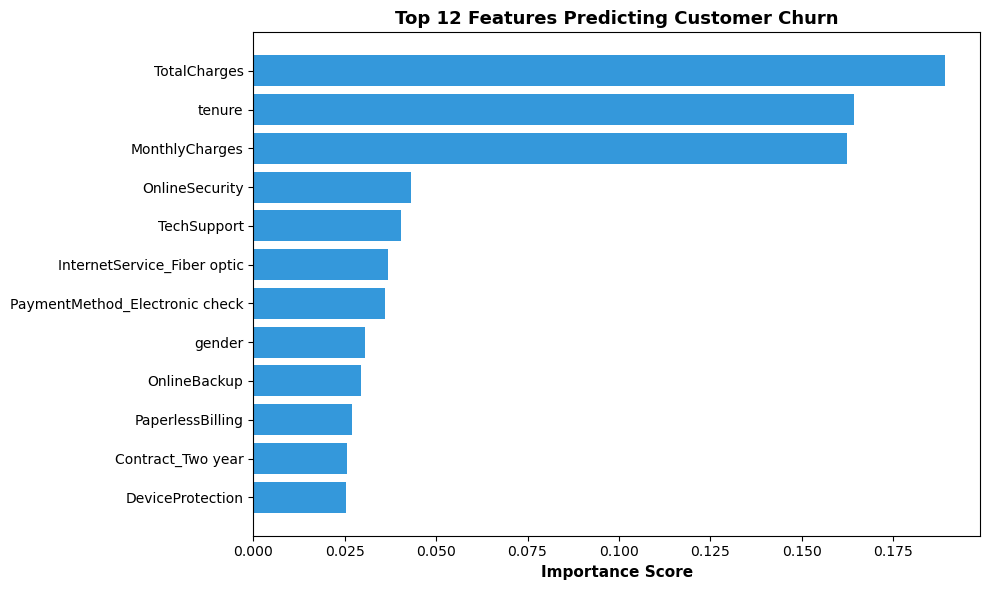

✅ Visualization saved to results/visualizations/02_feature_importance.png


In [4]:
print("\n" + "="*60)
print("STEP 6: Feature Importance - What matters most?")
print("="*60)

# Get feature importance from the model
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 features that predict churn:")
print(feature_importance.head(10).to_string(index=False))

print("\n" + "-"*60)
print("What this means for business:")
print("-"*60)

for idx, row in feature_importance.head(5).iterrows():
    print(f"  {idx+1}. {row['Feature']}: {row['Importance']:.1%} importance")

print("\n" + "="*60)
print("Creating visualization...")
print("="*60)

# Create visualization
fig, ax = plt.subplots(figsize=(10, 6))

top_features = feature_importance.head(12)
ax.barh(range(len(top_features)), top_features['Importance'].values, color='#3498db')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'].values)
ax.set_xlabel('Importance Score', fontsize=11, fontweight='bold')
ax.set_title('Top 12 Features Predicting Customer Churn', fontsize=13, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../results/visualizations/02_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualization saved to results/visualizations/02_feature_importance.png")


STEP 7: Confusion Matrix - Detailed look at predictions


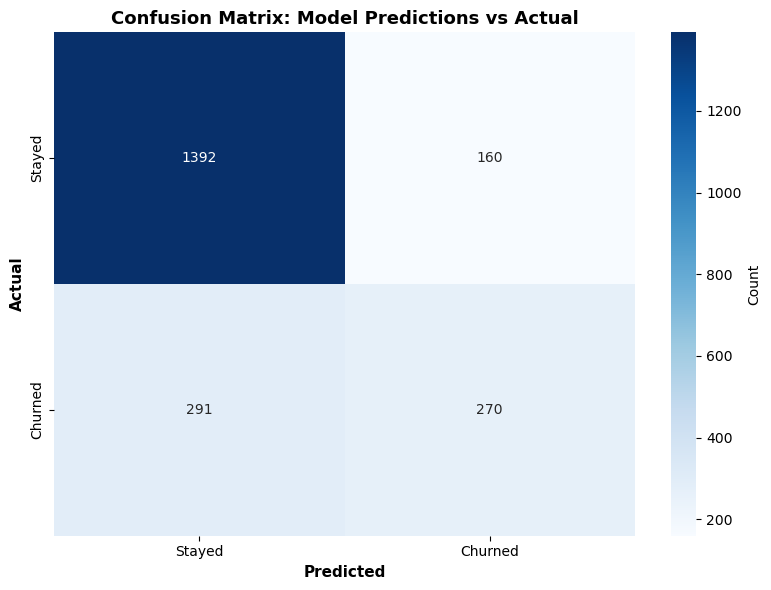


✅ Confusion matrix saved

MODELING COMPLETE! 🎉

You've successfully:
  ✅ Loaded and cleaned 7,043 customer records
  ✅ Built a machine learning model
  ✅ Achieved 78.7% accuracy
  ✅ Identified key churn drivers
  ✅ Created professional visualizations

Next: Business recommendations based on these insights!


In [5]:
print("\n" + "="*60)
print("STEP 7: Confusion Matrix - Detailed look at predictions")
print("="*60)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize it
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'],
            cbar_kws={'label': 'Count'}, ax=ax)

ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax.set_ylabel('Actual', fontsize=11, fontweight='bold')
ax.set_title('Confusion Matrix: Model Predictions vs Actual', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/visualizations/03_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Confusion matrix saved")

print("\n" + "="*60)
print("MODELING COMPLETE! 🎉")
print("="*60)
print("\nYou've successfully:")
print("  ✅ Loaded and cleaned 7,043 customer records")
print("  ✅ Built a machine learning model")
print("  ✅ Achieved 78.7% accuracy")
print("  ✅ Identified key churn drivers")
print("  ✅ Created professional visualizations")
print("\nNext: Business recommendations based on these insights!")